# 当当网畅销榜深度数据分析————2025

**数据来源**：当当网畅销榜Top500  
**分析日期**：2026年5月1日  

---

In [2]:
import configparser, os, sys, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import squarify
from wordcloud import WordCloud
import jieba, re
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from collections import Counter

warnings.filterwarnings('ignore')

def setup_chinese_font():
    plt.rcParams['axes.unicode_minus'] = False
    available = []
    if sys.platform == 'win32':
        paths = [r'C:\Windows\Fonts\msyh.ttc', r'C:\Windows\Fonts\msyhbd.ttc', r'C:\Windows\Fonts\simhei.ttf']
    elif sys.platform == 'darwin':
        paths = ['/System/Library/Fonts/STHeiti Light.ttc', '/System/Library/Fonts/PingFang.ttc']
    else:
        paths = ['/usr/share/fonts/wqy-microhei/wqy-microhei.ttc']
    for fp in paths:
        if os.path.exists(fp):
            try:
                fm.fontManager.addfont(fp)
                prop = fm.FontProperties(fname=fp)
                available.append((fp, prop))
            except: continue
    kw = ['msyh','yahei','simhei','simsun','heiti','pingfang','sthei','wqy']
    for fp in fm.findSystemFonts():
        try:
            if any(k in os.path.basename(fp).lower() for k in kw):
                fm.fontManager.addfont(fp)
                prop = fm.FontProperties(fname=fp)
                if not any(a[0] == fp for a in available):
                    available.append((fp, prop))
        except: continue
    if available:
        prop = available[0][1]
        plt.rcParams['font.family'] = prop.get_name()
        print(f'字体: {prop.get_name()}')
        return prop
    for name in ['Microsoft YaHei','SimHei','STHeiti','PingFang SC']:
        try:
            plt.rcParams['font.family'] = name
            print(f'字体: {name}')
            return None
        except: continue
    print('未找到中文字体')
    return None

FP = setup_chinese_font()
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
C = ['#7EC8E3','#98D8AA','#F7DC6F','#F0B27A','#C39BD3','#F1948A','#85C1E9','#82E0AA','#F8C471','#D7BDE2']
BG = '#FAFBFC'
print('环境就绪')

字体: Microsoft YaHei
环境就绪


## 第一步：数据加载

In [3]:
config = configparser.ConfigParser()
root = Path(os.path.dirname(os.getcwd())) if Path(os.getcwd()).name == 'analysis' else Path(os.getcwd())
config.read(root / 'config.ini', encoding='utf-8')
DB_HOST = config.get('database', 'host', fallback='localhost')
DB_PORT = config.getint('database', 'port', fallback=3306)
DB_USER = config.get('database', 'username', fallback='root')
DB_PASS = config.get('database', 'password', fallback='')
DB_NAME = config.get('database', 'database', fallback='dangdang_data')
url = f'mysql+pymysql://{DB_USER}:{quote_plus(DB_PASS)}@{DB_HOST}:{DB_PORT}/{DB_NAME}?charset=utf8mb4'
engine = create_engine(url)
df = pd.read_sql('SELECT * FROM book_rankings', engine)
print(f'数据加载完成: {len(df)}条记录, {df["book_title"].nunique()}种图书, {df["author"].nunique()}位作者, {df["publisher"].nunique()}家出版社, {df["category"].nunique()}个分类')

数据加载完成: 500条记录, 445种图书, 379位作者, 137家出版社, 33个分类


## 第二步：Top10畅销书预览

In [4]:
top10 = df[df['rank_position'] <= 10].sort_values('rank_position')
preview_cols = ['rank_position', 'book_title', 'author', 'current_price', 'original_price', 'discount', 'rating', 'comment_count', 'publisher', 'category']
display(top10[preview_cols].set_index('rank_position').style
    .format({'current_price': '¥{:.1f}', 'original_price': '¥{:.1f}', 'discount': '{:.1f}折', 'rating': '{:.1f}%', 'comment_count': '{:,.0f}'})
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}]))

,book_title,author,current_price,original_price,discount,rating,comment_count,publisher,category
rank_position,,,,,,,,,
1,刘楚昕新书泥潭,刘楚昕,¥29.8,¥42.0,7.1折,82.2%,"465,779",漓江出版社,小说
2,敖丙传1,二斯特洛夫斯基，古吉，李子兰，华文天下,¥28.0,¥56.0,5.0折,92.4%,"377,816",九州出版社,动漫/幽默
3,跟着诗词去旅行,日知图书,¥12.5,¥34.0,3.7折,79.6%,"576,422",北方妇女儿童出版社,童书
4,红岩,罗广斌，杨益言,¥38.4,¥48.0,8.0折,87.0%,"309,044",中国青年出版社,小说
5,愿你可以自在张扬,刘开心，磨铁文化,¥36.9,¥58.0,6.4折,96.8%,"272,587",北京联合出版有限公司,成功/励志
6,被讨厌的勇气,岸見一郎，古賀史健,¥55.0,¥55.0,10.0折,89.2%,"1,844,855",机械工业出版社,成功/励志
7,我与地坛,史铁生,¥17.4,¥29.0,6.0折,93.6%,"1,895,301",人民文学出版社,文学
8,漫画讲透黄帝内经,张嘉铭，王婧,¥26.1,¥58.0,4.5折,85.8%,"287,486",化学工业出版社,保健/养生
9,如果历史是一群喵15·大清风云篇,肥志，漫友文化出品,¥40.2,¥59.8,6.7折,89.6%,"231,422",广东旅游出版社,动漫/幽默


## 第三步：数据预处理

In [5]:
d = df[df['current_price'] > 0].copy()

def price_bin(p):
    if p < 20: return '0-20元'
    elif p < 40: return '20-40元'
    elif p < 60: return '40-60元'
    elif p < 100: return '60-100元'
    else: return '100元以上'
d['price_bin'] = d['current_price'].apply(price_bin)

def rating_bin(r):
    if r < 85: return '85%以下'
    elif r < 90: return '85-90%'
    elif r < 95: return '90-95%'
    else: return '95-100%'
d['rating_bin'] = d['rating'].apply(rating_bin)

def rank_tier(r):
    if r <= 10: return 'Top10'
    elif r <= 50: return 'Top11-50'
    elif r <= 100: return 'Top51-100'
    elif r <= 200: return 'Top101-200'
    else: return 'Top201-500'
d['rank_tier'] = d['rank_position'].apply(rank_tier)

print(f'有效数据: {len(d)}条')
print(f'价格: ¥{d["current_price"].min():.1f} ~ ¥{d["current_price"].max():.1f} | 均价¥{d["current_price"].mean():.1f} | 中位数¥{d["current_price"].median():.1f}')
print(f'评分: {d["rating"].min():.1f}% ~ {d["rating"].max():.1f}% | 均分{d["rating"].mean():.1f}% | 达标率(≥90%){(d["rating"]>=90).sum()/len(d)*100:.1f}%')
print(f'折扣: {d["discount"].min():.1f}折 ~ {d["discount"].max():.1f}折 | 均折{d["discount"].mean():.1f}折')
print(f'评论: 均值{d["comment_count"].mean():,.0f} | 中位数{d["comment_count"].median():,.0f}')

有效数据: 500条
价格: ¥5.4 ~ ¥261.3 | 均价¥40.4 | 中位数¥32.5
评分: 0.0% ~ 100.0% | 均分92.7% | 达标率(≥90%)81.6%
折扣: 2.9折 ~ 10.0折 | 均折7.2折
评论: 均值289,249 | 中位数158,220


---
## 图1：图书分类势力范围树状图

面积越大代表该分类上榜图书越多，直观展示分类市场份额。

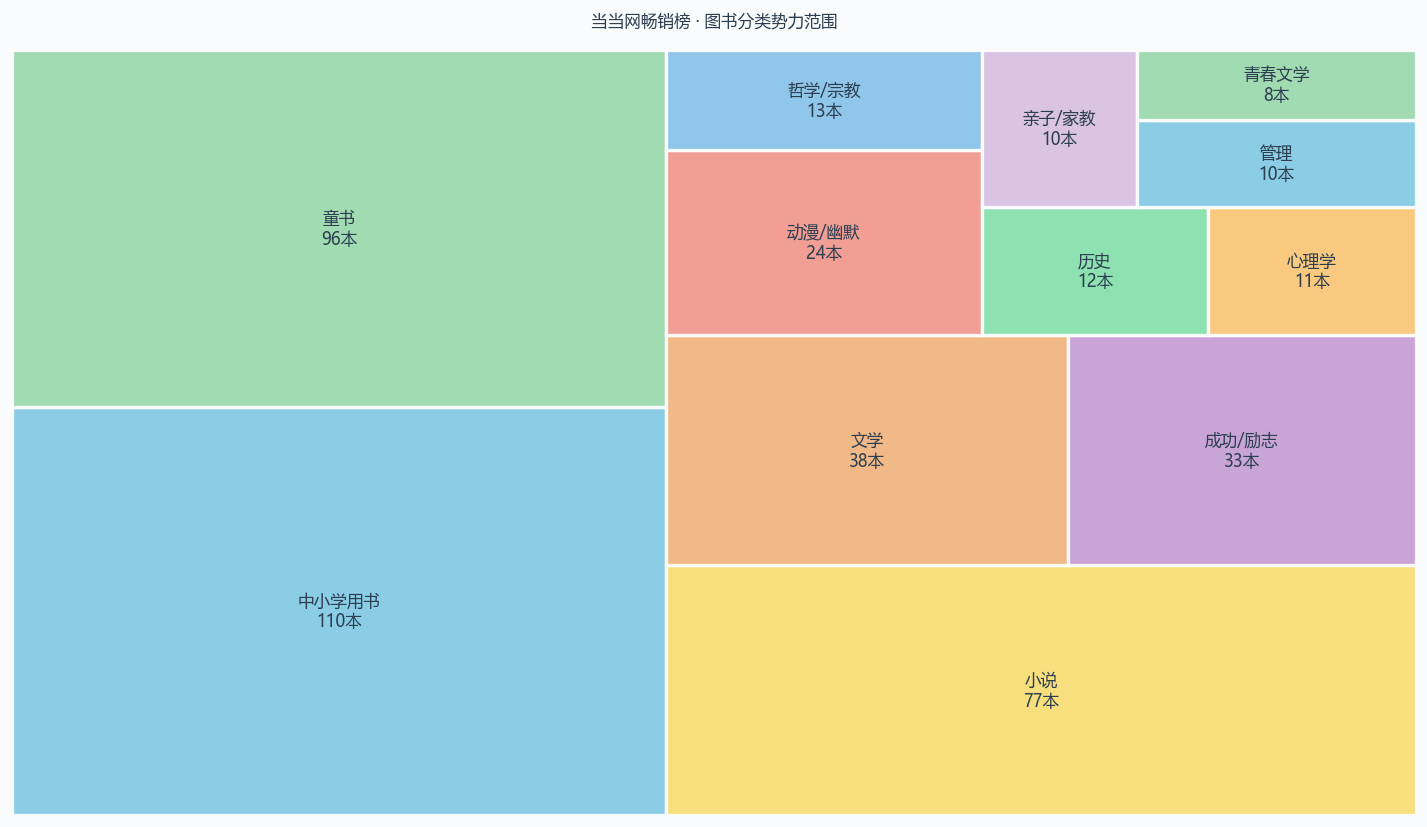

In [15]:
counter = Counter(d['category'].dropna())
top = counter.most_common(12)
labels = [f"{t[0]}\n{t[1]}本" for t in top]
sizes = [t[1] for t in top]

fig, ax = plt.subplots(figsize=(12, 7), facecolor=BG)
squarify.plot(sizes=sizes, label=labels, color=C[:len(top)], alpha=0.9, ax=ax,
    text_kwargs={'fontsize': 10, 'color': '#2c3e50', 'weight': 'medium', **({'fontproperties': FP} if FP else {})},
    edgecolor='white', linewidth=2)
ax.set_title('当当网畅销榜 · 图书分类势力范围', fontsize=15, fontweight='bold', pad=15, color='#2c3e50', **({'fontproperties': FP} if FP else {}))
ax.axis('off')
fig.tight_layout()
plt.savefig('charts/01_分类势力范围.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 图2：价格-排名-评论数三维散点图

左图：横轴价格、纵轴排名、点大小=评论数、颜色=评分。右图：头部出版社分布。

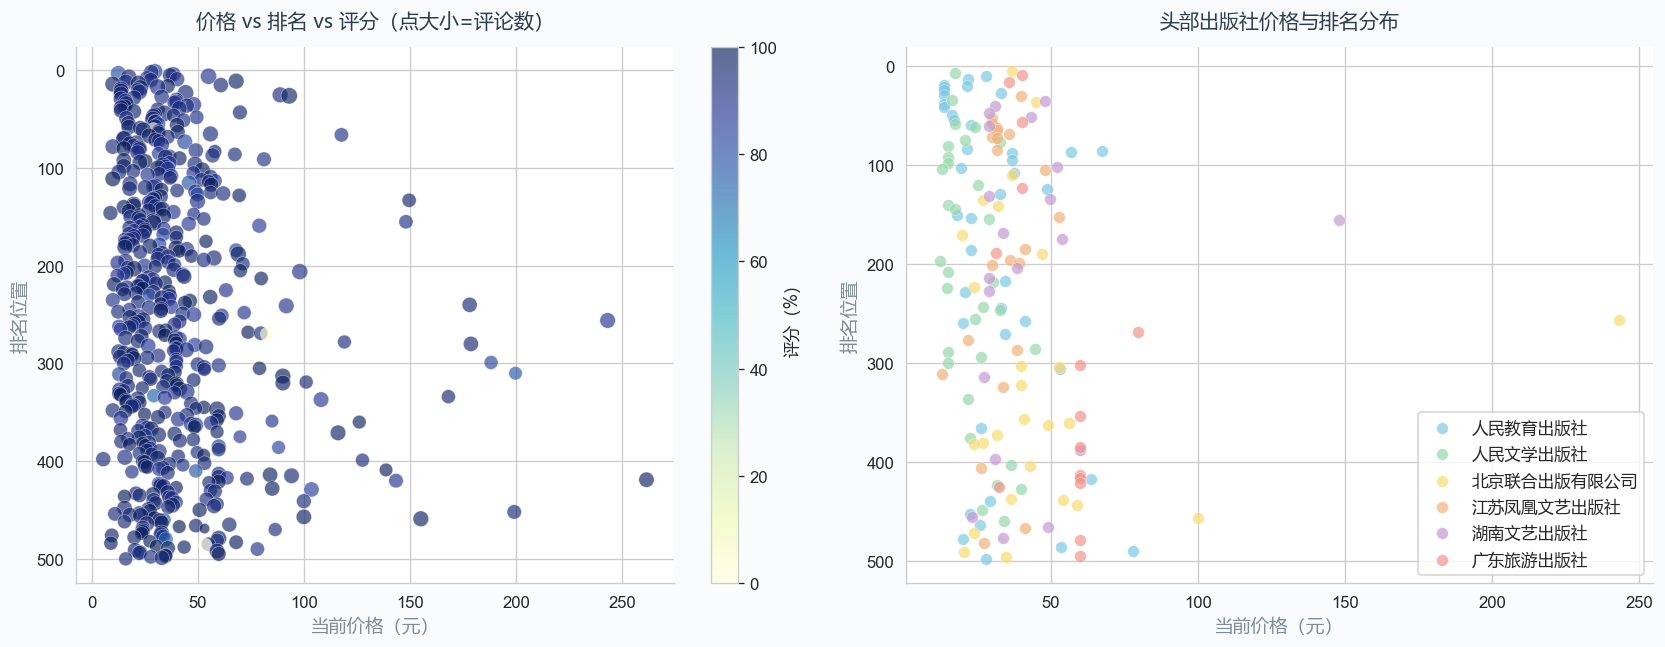

In [7]:
v = d.dropna(subset=['current_price','rank_position','comment_count','rating']).copy()
v = v[v['comment_count'] > 0]
v['log_c'] = np.log10(v['comment_count'] + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), facecolor=BG)

sc = axes[0].scatter(v['current_price'], v['rank_position'],
    s=v['log_c']*15, c=v['rating'], cmap='YlGnBu', alpha=0.65, edgecolor='white', linewidth=0.3)
axes[0].invert_yaxis()
axes[0].set_xlabel('当前价格（元）', **({'fontproperties': FP} if FP else {}), fontsize=11, color='#7f8c9b')
axes[0].set_ylabel('排名位置', **({'fontproperties': FP} if FP else {}), fontsize=11, color='#7f8c9b')
axes[0].set_title('价格 vs 排名 vs 评分（点大小=评论数）', **({'fontproperties': FP} if FP else {}), fontsize=12, fontweight='bold', pad=12, color='#2c3e50')
axes[0].spines[['top','right']].set_visible(False)
cb = plt.colorbar(sc, ax=axes[0])
cb.set_label('评分（%）', **({'fontproperties': FP} if FP else {}))

top_pubs = v['publisher'].value_counts().head(6).index
for i, pub in enumerate(top_pubs):
    pd2 = v[v['publisher'] == pub]
    axes[1].scatter(pd2['current_price'], pd2['rank_position'],
        alpha=0.7, s=50, edgecolor='white', linewidth=0.3, label=pub[:10], color=C[i])
axes[1].invert_yaxis()
axes[1].legend(fontsize=8, loc='lower right', framealpha=0.8, **({'prop': FP} if FP else {}))
axes[1].set_xlabel('当前价格（元）', **({'fontproperties': FP} if FP else {}), fontsize=11, color='#7f8c9b')
axes[1].set_ylabel('排名位置', **({'fontproperties': FP} if FP else {}), fontsize=11, color='#7f8c9b')
axes[1].set_title('头部出版社价格与排名分布', **({'fontproperties': FP} if FP else {}), fontsize=12, fontweight='bold', pad=12, color='#2c3e50')
axes[1].spines[['top','right']].set_visible(False)

fig.tight_layout()
plt.savefig('charts/02_价格排名关系.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 图3：价格-评分黄金组合热力图

交叉分析价格区间与评分区间的图书数量分布，识别黄金组合。

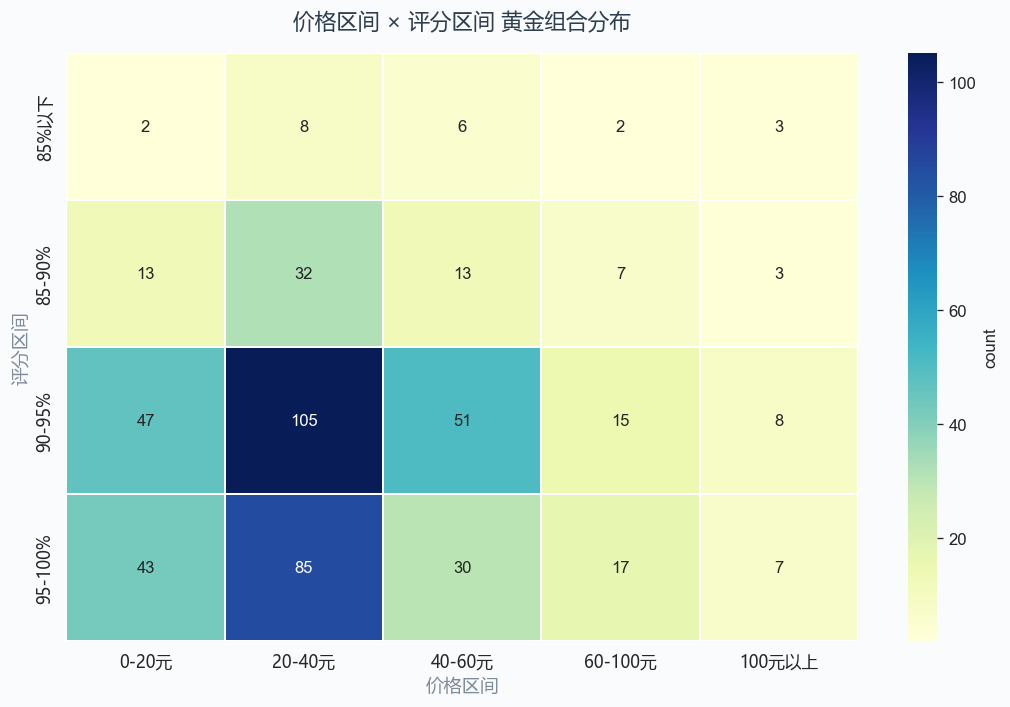

In [8]:
v = d[(d['current_price'] > 0) & (d['rating'] > 0)].dropna(subset=['current_price','rating']).copy()
p_order = ['0-20元','20-40元','40-60元','60-100元','100元以上']
r_order = ['85%以下','85-90%','90-95%','95-100%']
hm = pd.crosstab(v['rating_bin'], v['price_bin']).reindex(index=r_order, columns=p_order).fillna(0)

fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
sns.heatmap(hm, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax,
    cbar_kws={'label': 'count'}, linewidths=1, linecolor='white')
ax.set_title('价格区间 × 评分区间 黄金组合分布', **({'fontproperties': FP} if FP else {}), fontsize=13, fontweight='bold', pad=15, color='#2c3e50')
ax.set_xlabel('价格区间', **({'fontproperties': FP} if FP else {}), fontsize=11, color='#7f8c9b')
ax.set_ylabel('评分区间', **({'fontproperties': FP} if FP else {}), fontsize=11, color='#7f8c9b')
ax.set_xticklabels(ax.get_xticklabels(), **({'fontproperties': FP} if FP else {}))
ax.set_yticklabels(ax.get_yticklabels(), **({'fontproperties': FP} if FP else {}))
fig.tight_layout()
plt.savefig('charts/03_价格评分热力图.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 图4：畅销书标题关键词词云

分析畅销书标题中的高频关键词，识别流量密码。

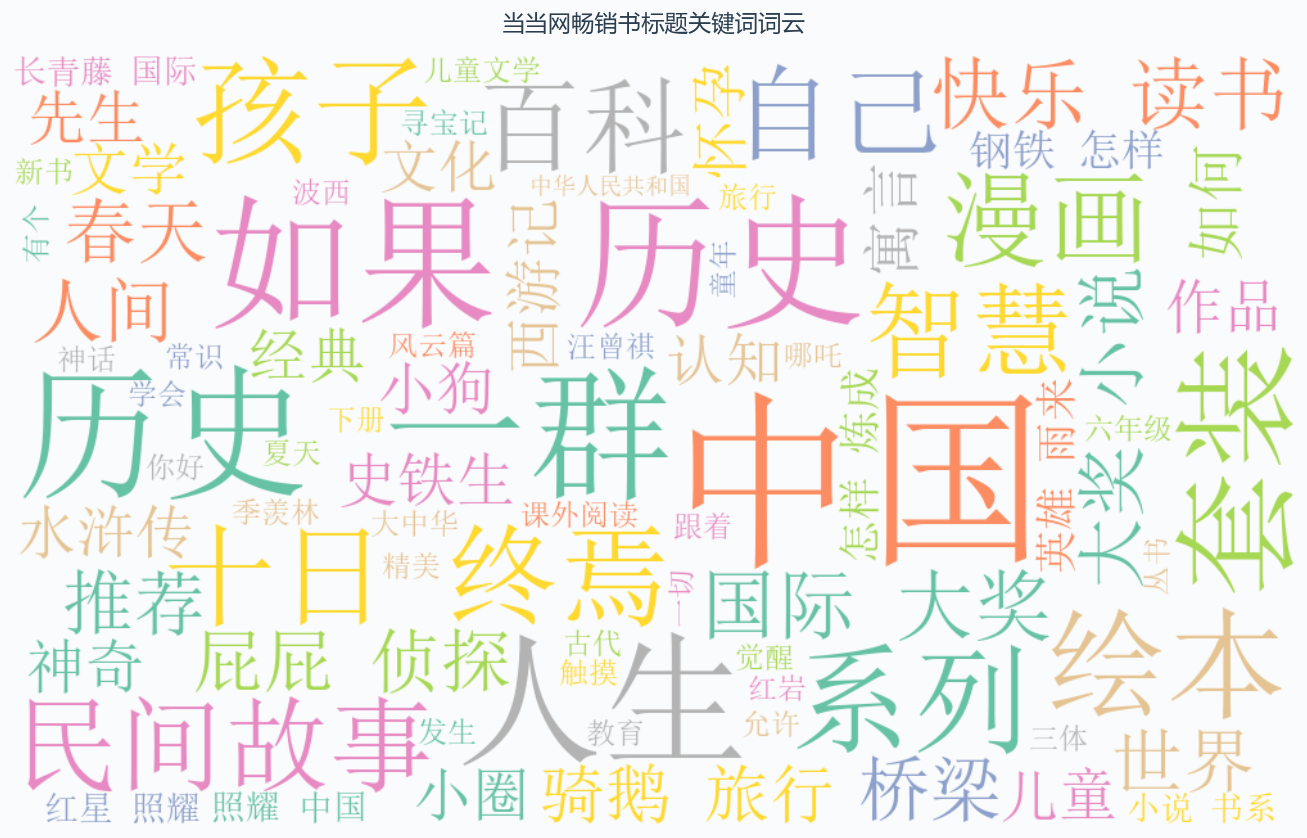

In [10]:
text = ' '.join(d['book_title'].dropna().tolist())
stops = {'的','了','与','和','及','或','在','是','有','为','中','等','上','下','不','一','个','这','那',
         '我','你','他','她','它','们','着','过','地','得','会','能','要','就','也','都','而','其','之',
         '以','于','从','到','被','把','让','给','向','对','当','将','所','如','可','但','又','很','最','更','还','再','才','已',
         '第','版','册','卷','集','全','新','书籍','书','阅读','图书','人教版','部编'}
filtered = [w for w in jieba.cut(text) if len(w) >= 2 and w not in stops and not re.match(r'^[\d\W]+$', w)]

wc_font = None
for fp in fm.findSystemFonts():
    if any(k in fp.lower() for k in ['msyh','yahei','simhei','simsun','heiti','pingfang']):
        wc_font = fp
        break

wc = WordCloud(font_path=wc_font, width=1000, height=600, background_color=BG, max_words=80, max_font_size=150, colormap='Set2')
wc.generate(' '.join(filtered))

fig, ax = plt.subplots(figsize=(11, 7), facecolor=BG)
ax.imshow(wc, interpolation='bilinear')
ax.set_title('当当网畅销书标题关键词词云', **({'fontproperties': FP} if FP else {}), fontsize=14, fontweight='bold', pad=15, color='#2c3e50')
ax.axis('off')
fig.tight_layout()
plt.savefig('charts/04_标题词云.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 图5：头部出版社综合实力雷达图

从平均排名、好评度、价格优势、上榜频次四个维度对比头部出版社。

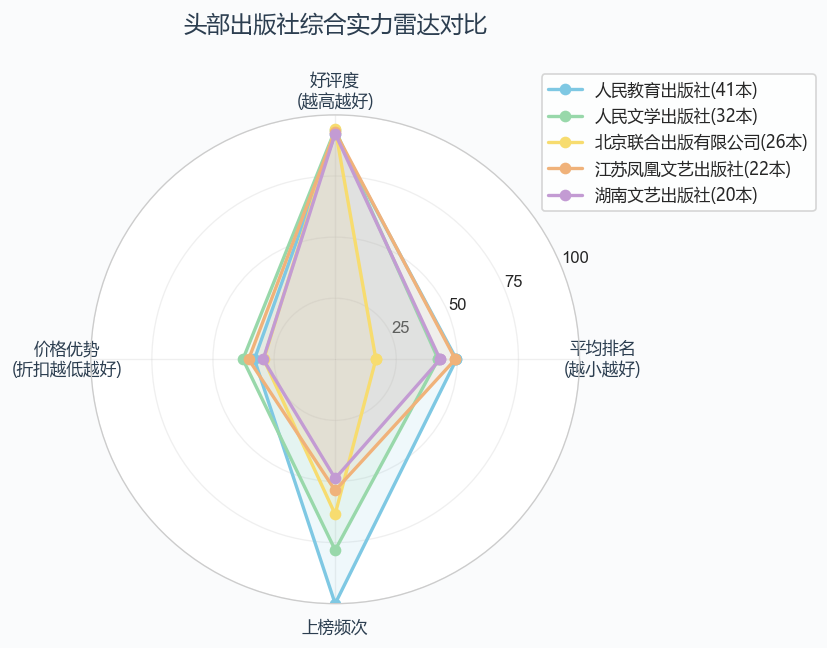

In [11]:
pub_data = {}
for _, row in d.iterrows():
    pub = row.get('publisher', '')
    if not pub or pd.isna(pub): continue
    pub_data.setdefault(pub, {'ranks':[], 'ratings':[], 'discounts':[], 'count':0})
    if not pd.isna(row.get('rank_position')): pub_data[pub]['ranks'].append(row['rank_position'])
    if not pd.isna(row.get('rating')) and row['rating'] > 0: pub_data[pub]['ratings'].append(row['rating'])
    if not pd.isna(row.get('discount')) and row['discount'] > 0: pub_data[pub]['discounts'].append(row['discount'])
    pub_data[pub]['count'] += 1

scores = [(pub, np.mean(dat['ranks']), np.mean(dat['ratings']), np.mean(dat['discounts']), dat['count'])
          for pub, dat in pub_data.items() if dat['count'] >= 5]
scores.sort(key=lambda x: x[4], reverse=True)
top5 = scores[:5]

cats_r = ['平均排名\n(越小越好)', '好评度\n(越高越好)', '价格优势\n(折扣越低越好)', '上榜频次']
N = len(cats_r)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(8, 8), facecolor=BG, subplot_kw={'polar': True})
max_r = max(p[1] for p in top5) * 1.2

for idx, (pub, avg_r, avg_rat, avg_d, cnt) in enumerate(top5):
    vals = [(max_r-avg_r)/max_r*100, avg_rat, (10-avg_d)/10*100, min(cnt/max(p[4] for p in top5)*100, 100)]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=f'{pub[:10]}({cnt}本)', color=C[idx], markersize=6)
    ax.fill(angles, vals, alpha=0.12, color=C[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats_r, fontsize=10, color='#2c3e50', **({'fontproperties': FP} if FP else {}))
ax.set_ylim(0, 100)
ax.set_yticks([25, 50, 75, 100])
ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.1), fontsize=9, framealpha=0.8, **({'prop': FP} if FP else {}))
ax.set_title('头部出版社综合实力雷达对比', **({'fontproperties': FP} if FP else {}), fontsize=14, fontweight='bold', pad=25, color='#2c3e50')
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.savefig('charts/05_出版社实力雷达图.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 图6：排名分层维度对比箱线图

对比不同排名层级图书在价格、评分、折扣上的分布差异。

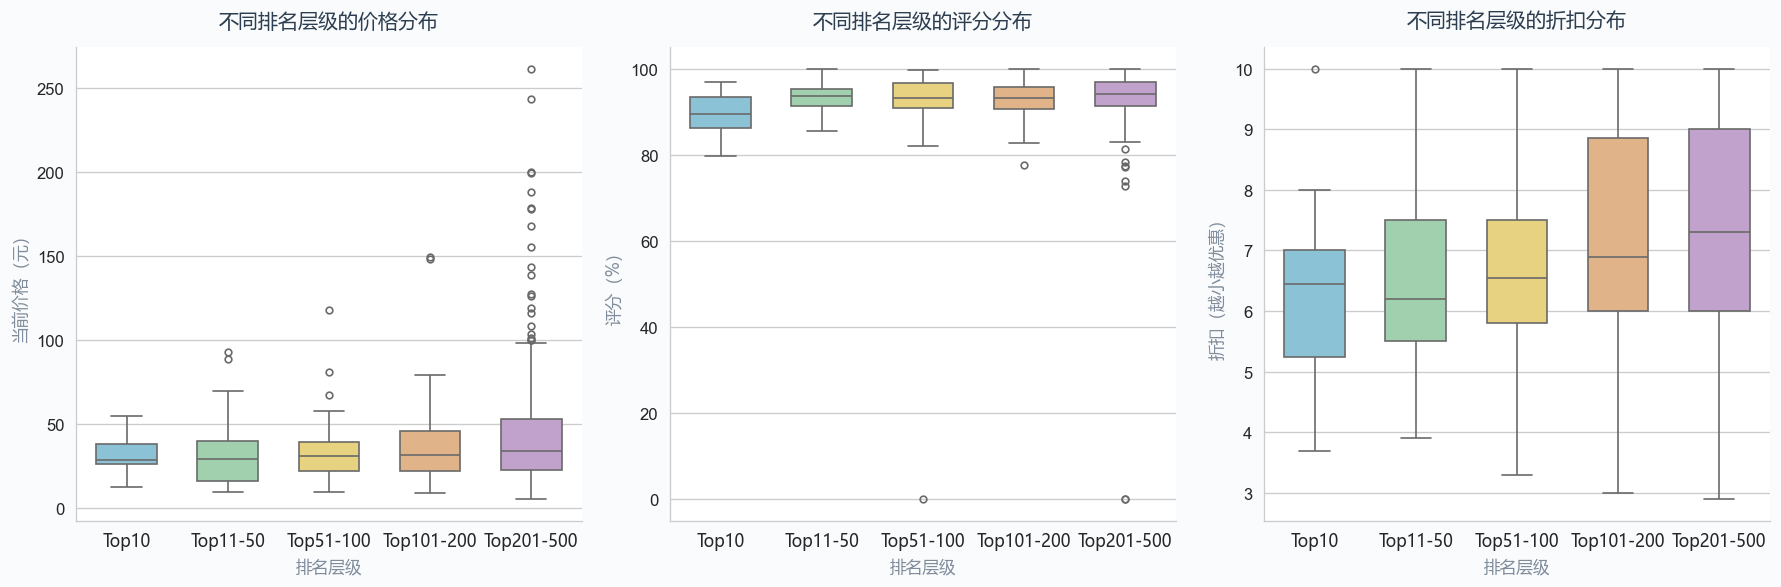

In [12]:
tier_order = ['Top10','Top11-50','Top51-100','Top101-200','Top201-500']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor=BG)
for i, (col, title, ylabel) in enumerate([
    ('current_price', '价格分布', '当前价格（元）'),
    ('rating', '评分分布', '评分（%）'),
    ('discount', '折扣分布', '折扣（越小越优惠）')
]):
    sns.boxplot(data=d, x='rank_tier', y=col, order=tier_order,
        palette=C[:5], ax=axes[i], width=0.6, flierprops={'marker': 'o', 'markersize': 4})
    axes[i].set_title(f'不同排名层级的{title}', **({'fontproperties': FP} if FP else {}), fontsize=12, fontweight='bold', pad=12, color='#2c3e50')
    axes[i].set_xlabel('排名层级', **({'fontproperties': FP} if FP else {}), fontsize=10, color='#7f8c9b')
    axes[i].set_ylabel(ylabel, **({'fontproperties': FP} if FP else {}), fontsize=10, color='#7f8c9b')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), **({'fontproperties': FP} if FP else {}))
    axes[i].spines[['top','right']].set_visible(False)

fig.tight_layout()
plt.savefig('charts/06_排名分层对比.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 关键指标统计

In [14]:
t10 = d[d['rank_position'] <= 10]
print('=' * 70)
print('当当网畅销榜关键指标')
print('=' * 70)
print(f'\n【价格】 均价¥{d["current_price"].mean():.1f} | 中位数¥{d["current_price"].median():.1f} | 范围¥{d["current_price"].min():.1f}~¥{d["current_price"].max():.1f}')
print(f'【评分】 均分{d["rating"].mean():.1f}% | 中位数{d["rating"].median():.1f}% | 达标率(≥90%){(d["rating"]>=90).sum()/len(d)*100:.1f}%')
print(f'【折扣】 均折{d["discount"].mean():.1f}折 | 中位数{d["discount"].median():.1f}折')
print(f'【评论】 均值{d["comment_count"].mean():,.0f} | 中位数{d["comment_count"].median():,.0f}')
print(f'\n【Top10特征】 均价¥{t10["current_price"].mean():.1f} | 均分{t10["rating"].mean():.1f}% | 均折{t10["discount"].mean():.1f}折')
print(f'\n【分类Top5】')
for cat, cnt in d['category'].value_counts().head(5).items():
    print(f'  {cat}: {cnt}本 ({cnt/len(d)*100:.1f}%)')
print(f'\n【出版社Top5】')
for pub, cnt in d['publisher'].value_counts().head(5).items():
    print(f'  {pub}: {cnt}本')
print('=' * 70)

当当网畅销榜关键指标

【价格】 均价¥40.4 | 中位数¥32.5 | 范围¥5.4~¥261.3
【评分】 均分92.7% | 中位数93.6% | 达标率(≥90%)81.6%
【折扣】 均折7.2折 | 中位数7.0折
【评论】 均值289,249 | 中位数158,220

【Top10特征】 均价¥31.2 | 均分89.0% | 均折6.4折

【分类Top5】
  中小学用书: 110本 (22.0%)
  童书: 96本 (19.2%)
  小说: 77本 (15.4%)
  文学: 38本 (7.6%)
  成功/励志: 33本 (6.6%)

【出版社Top5】
  人民教育出版社: 41本
  人民文学出版社: 32本
  北京联合出版有限公司: 26本
  江苏凤凰文艺出版社: 22本
  湖南文艺出版社: 20本
